In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
df = pd.read_csv("mental_health_survey.csv")

In [176]:
df =df.drop(['Timestamp','comments','state'],axis=1)

In [177]:
df2 = df.copy()

In [178]:
df.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,M,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


In [179]:
df.columns

Index(['Age', 'Gender', 'Country', 'self_employed', 'family_history',
       'treatment', 'work_interfere', 'no_employees', 'remote_work',
       'tech_company', 'benefits', 'care_options', 'wellness_program',
       'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
       'phys_health_consequence', 'coworkers', 'supervisor',
       'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence'],
      dtype='object')

In [180]:
cat_cols = [
    'Gender', 'Country', 'self_employed', 'family_history',
    'treatment', 'work_interfere', 'no_employees', 'remote_work',
    'tech_company', 'benefits', 'care_options', 'wellness_program',
    'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
    'phys_health_consequence', 'coworkers', 'supervisor',
    'mental_health_interview', 'phys_health_interview',
    'mental_vs_physical', 'obs_consequence'
]


num_cols = ['Age']

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1259 non-null   int64 
 1   Gender                     1259 non-null   object
 2   Country                    1259 non-null   object
 3   self_employed              1241 non-null   object
 4   family_history             1259 non-null   object
 5   treatment                  1259 non-null   object
 6   work_interfere             995 non-null    object
 7   no_employees               1259 non-null   object
 8   remote_work                1259 non-null   object
 9   tech_company               1259 non-null   object
 10  benefits                   1259 non-null   object
 11  care_options               1259 non-null   object
 12  wellness_program           1259 non-null   object
 13  seek_help                  1259 non-null   object
 14  anonymit

In [182]:
df.drop_duplicates()
df.shape

(1259, 24)

In [183]:
df['Gender'].value_counts()

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female                                              2
Female (trans)                                      2
Male-ish                                            1
Trans-female                                        1
Male (CIS)                                          1
Mal                  

In [184]:
df.isnull().sum()  # self_employed ,work_interfere

Age                            0
Gender                         0
Country                        0
self_employed                 18
family_history                 0
treatment                      0
work_interfere               264
no_employees                   0
remote_work                    0
tech_company                   0
benefits                       0
care_options                   0
wellness_program               0
seek_help                      0
anonymity                      0
leave                          0
mental_health_consequence      0
phys_health_consequence        0
coworkers                      0
supervisor                     0
mental_health_interview        0
phys_health_interview          0
mental_vs_physical             0
obs_consequence                0
dtype: int64

In [185]:
df[df['work_interfere'].isnull()]
#Filling the NULL values : 
df['work_interfere'] = df['work_interfere'].fillna('Unknown')

In [186]:
df[df['self_employed'].isnull()]
#Filling the NULL values : 
df['self_employed'] = df['self_employed'].fillna('No')

In [187]:

gender_map = {
    'Male': 'Male', 'male': 'Male', 'M': 'Male', 'm': 'Male', 'Make': 'Male', 
    'Male ': 'Male', 'Man': 'Male', 'Cis Male': 'Male', 'Male (CIS)': 'Male', 
    'Mal': 'Male', 'maile': 'Male', 'msle': 'Male', 'Mail': 'Male', 
    'cis male': 'Male', 'Malr': 'Male', 'Cis Man': 'Male', 'Male-ish': 'Male', 
    'something kinda male?': 'Male', 'male leaning androgynous': 'Male', 'Guy (-ish) ^_^': 'Male',

    'Female': 'Female', 'female': 'Female', 'F': 'Female', 'f': 'Female', 
    'female ': 'Female', 'Woman': 'Female', 'Cis Female': 'Female', 'woman': 'Female', 
    'Femake': 'Female', 'cis-female/femme': 'Female', 'Female (cis)': 'Female', 'femail': 'Female',

    'Female (trans)': 'Other', 'Trans-female': 'Other', 'queer/she/they': 'Other', 
    'Enby': 'Other', 'fluid': 'Other', 'Genderqueer': 'Other', 'Androgyne': 'Other', 
    'Agender': 'Other', 'non-binary': 'Other', 'Trans woman': 'Other', 'queer': 'Other',
    
    'Nah': 'Other', 'All': 'Other', 'Neuter': 'Other', 'A little about you': 'Other', 
    'p': 'Other', 'ostensibly male, unsure what that really means': 'Male' # (অথবা 'Other')
}

df['Gender'] = df['Gender'].map(gender_map)

df['Gender'] = df['Gender'].fillna('Other')

In [188]:
df['Gender'].value_counts()

Gender
Male      995
Female    245
Other      19
Name: count, dtype: int64

In [189]:
country_counts = df['Country'].value_counts()
top_countries = country_counts.nlargest(5).index.tolist()

df['Country'] = df['Country'].apply(lambda x: x if x in top_countries else 'Other')

In [190]:
for col in cat_cols:
    print(df[col].value_counts())
    print('\n')

Gender
Male      995
Female    245
Other      19
Name: count, dtype: int64


Country
United States     751
United Kingdom    185
Other             179
Canada             72
Germany            45
Netherlands        27
Name: count, dtype: int64


self_employed
No     1113
Yes     146
Name: count, dtype: int64


family_history
No     767
Yes    492
Name: count, dtype: int64


treatment
Yes    637
No     622
Name: count, dtype: int64


work_interfere
Sometimes    465
Unknown      264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64


no_employees
6-25              290
26-100            289
More than 1000    282
100-500           176
1-5               162
500-1000           60
Name: count, dtype: int64


remote_work
No     883
Yes    376
Name: count, dtype: int64


tech_company
Yes    1031
No      228
Name: count, dtype: int64


benefits
Yes           477
Don't know    408
No            374
Name: count, dtype: int64


care_options
No          501
Yes         444


In [191]:
df3=df.copy()

In [192]:
import pandas as pd

#dict mapping to numerical numbers (max to min)
mapping = {
    'Gender': {'Male': 3, 'Female': 2, 'Other': 1},
    
    'Country': {
        'United States': 6, 'United Kingdom': 5, 'Other': 4, 
        'Canada': 3, 'Germany': 2, 'Netherlands': 1
    },
    
    'self_employed': {'No': 2, 'Yes': 1},
    
    'family_history': {'No': 2, 'Yes': 1},
    
    'treatment': {'Yes': 2, 'No': 1},
    
    'work_interfere': {'Sometimes': 5,'Unknown' : 4 ,'Never': 3, 'Rarely': 2, 'Often': 1},
    
    'no_employees': {
        '6-25': 6, '26-100': 5, 'More than 1000': 4, 
        '100-500': 3, '1-5': 2, '500-1000': 1
    },
    
    'remote_work': {'No': 2, 'Yes': 1},
    
    'tech_company': {'Yes': 2, 'No': 1},
    
    'benefits': {'Yes': 3, "Don't know": 2, 'No': 1},
    
    'care_options': {'No': 3, 'Yes': 2, 'Not sure': 1},
    
    'wellness_program': {'No': 3, 'Yes': 2, "Don't know": 1},
    
    'seek_help': {'No': 3, "Don't know": 2, 'Yes': 1},
    
    'anonymity': {"Don't know": 3, 'Yes': 2, 'No': 1},
    
    'leave': {
        "Don't know": 5, 'Somewhat easy': 4, 'Very easy': 3, 
        'Somewhat difficult': 2, 'Very difficult': 1
    },
    
    'mental_health_consequence': {'No': 3, 'Maybe': 2, 'Yes': 1},
    
    'phys_health_consequence': {'No': 3, 'Maybe': 2, 'Yes': 1},
    
    'coworkers': {'Some of them': 3, 'No': 2, 'Yes': 1},
    
    'supervisor': {'Yes': 3, 'No': 2, 'Some of them': 1},
    
    'mental_health_interview': {'No': 3, 'Maybe': 2, 'Yes': 1},
    
    'phys_health_interview': {'Maybe': 3, 'No': 2, 'Yes': 1},
    
    'mental_vs_physical': {"Don't know": 3, 'Yes': 2, 'No': 1},
    
    'obs_consequence': {'No': 2, 'Yes': 1}
}

# Mapping the data frame
for col, map_dict in mapping.items():
    if col in df.columns:
        df[col] = df[col].map(map_dict)

In [193]:
for col in cat_cols:
    print(df[col].value_counts())
    print('\n')

Gender
3    995
2    245
1     19
Name: count, dtype: int64


Country
6    751
5    185
4    179
3     72
2     45
1     27
Name: count, dtype: int64


self_employed
2    1113
1     146
Name: count, dtype: int64


family_history
2    767
1    492
Name: count, dtype: int64


treatment
2    637
1    622
Name: count, dtype: int64


work_interfere
5    465
4    264
3    213
2    173
1    144
Name: count, dtype: int64


no_employees
6    290
5    289
4    282
3    176
2    162
1     60
Name: count, dtype: int64


remote_work
2    883
1    376
Name: count, dtype: int64


tech_company
2    1031
1     228
Name: count, dtype: int64


benefits
3    477
2    408
1    374
Name: count, dtype: int64


care_options
3    501
2    444
1    314
Name: count, dtype: int64


wellness_program
3    842
2    229
1    188
Name: count, dtype: int64


seek_help
3    646
2    363
1    250
Name: count, dtype: int64


anonymity
3    819
2    375
1     65
Name: count, dtype: int64


leave
5    563
4    266
3    206


C:\Users\Acer\AppData\Local\Temp\ipykernel_17836\2884328128.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,4))


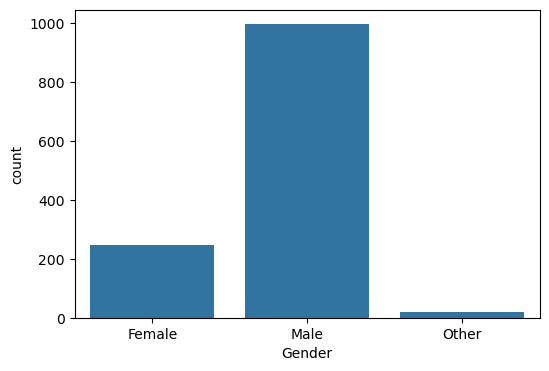

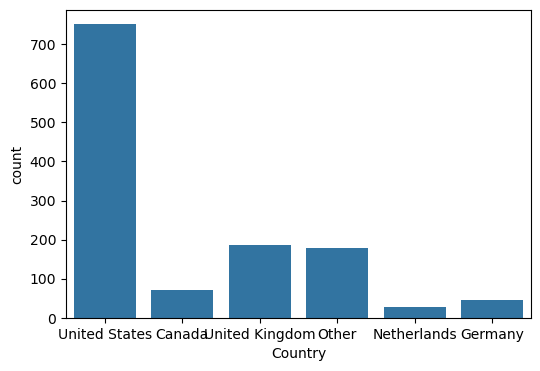

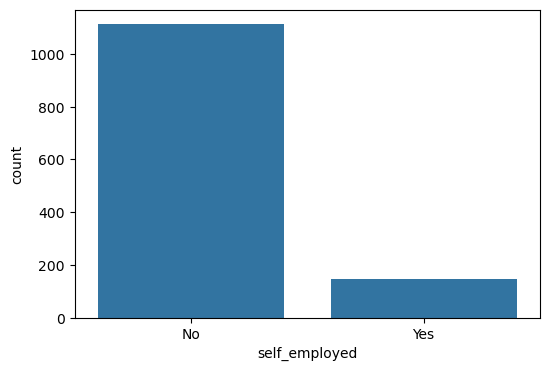

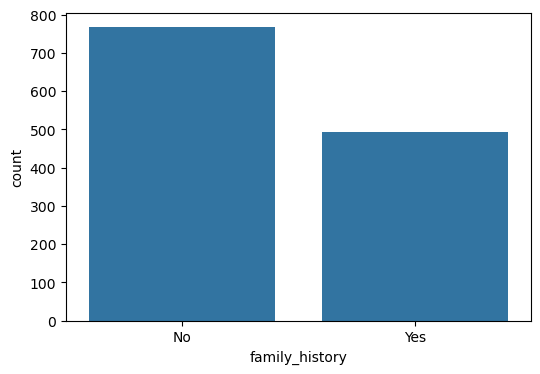

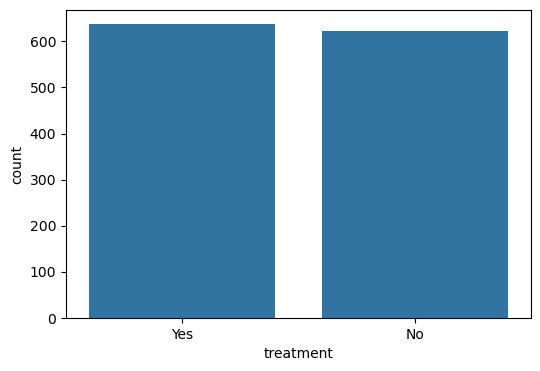

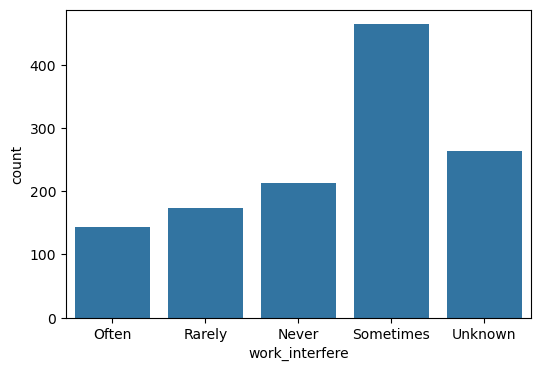

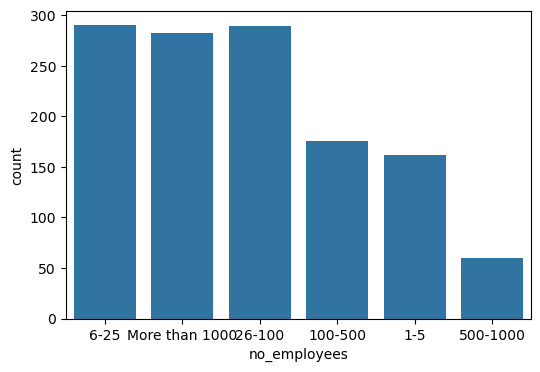

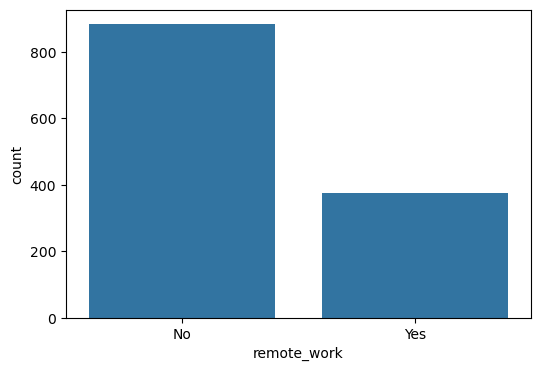

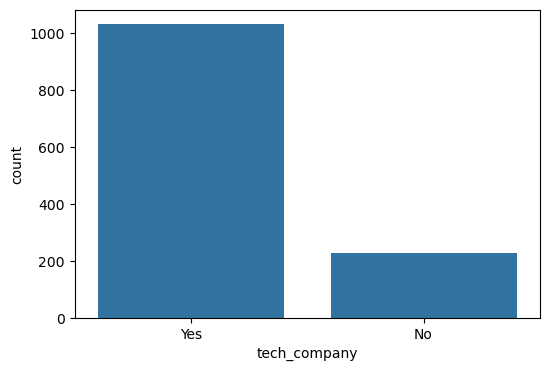

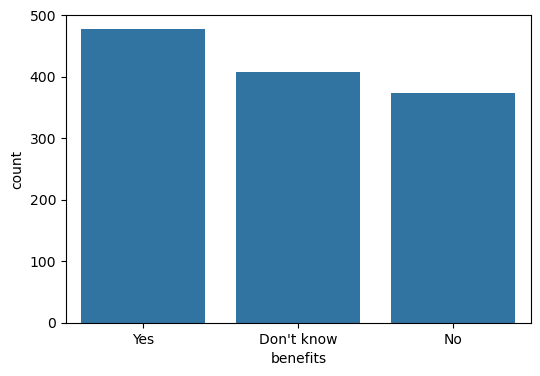

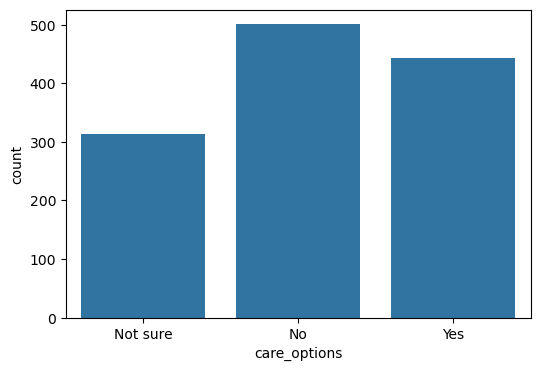

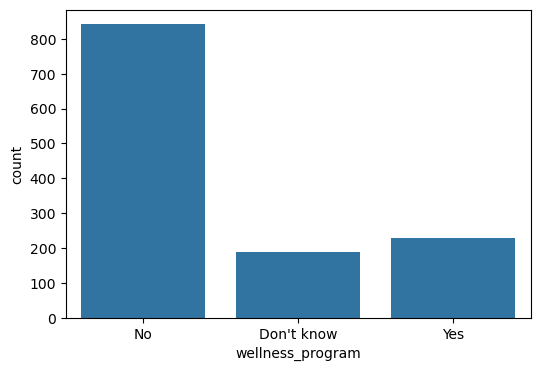

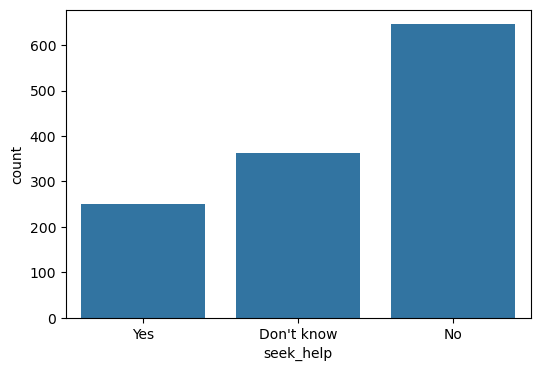

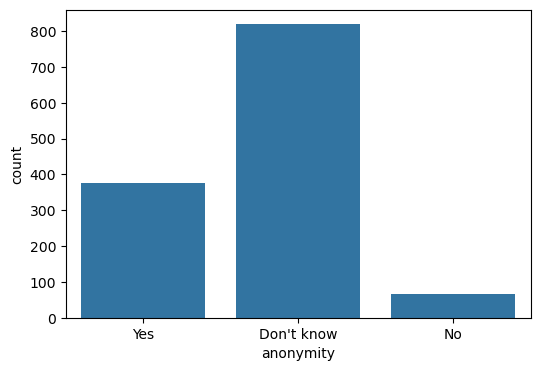

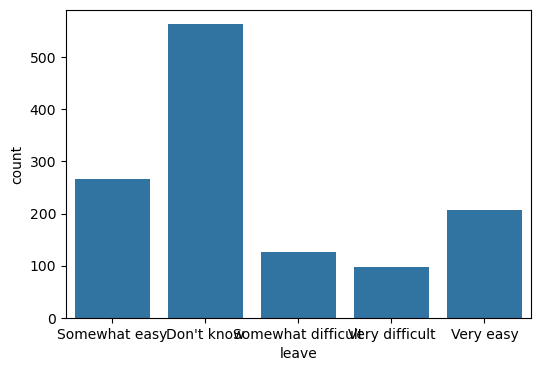

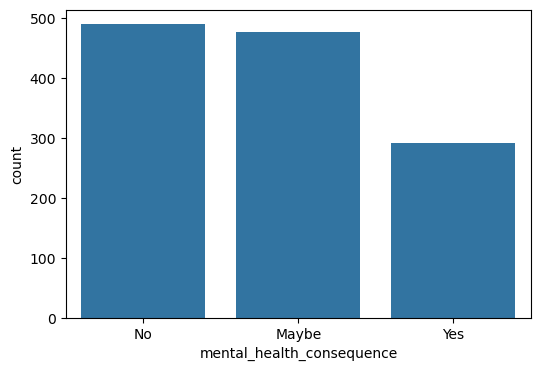

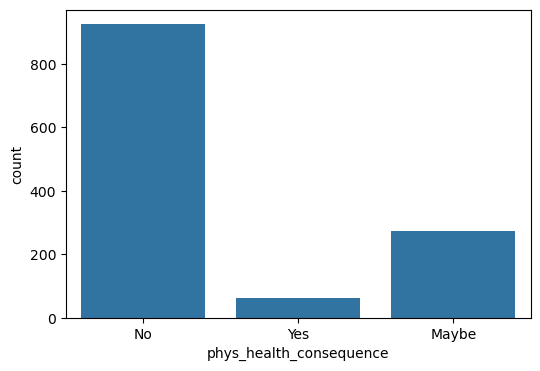

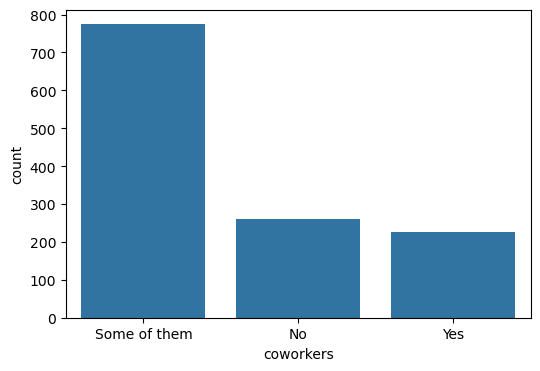

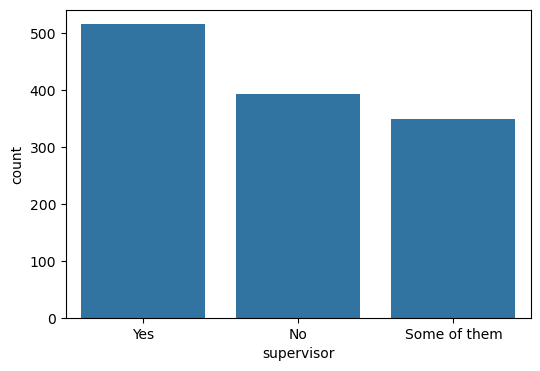

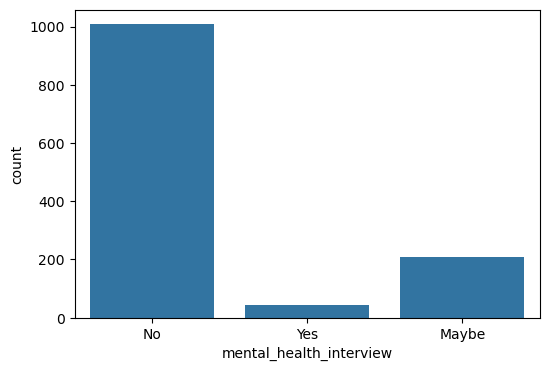

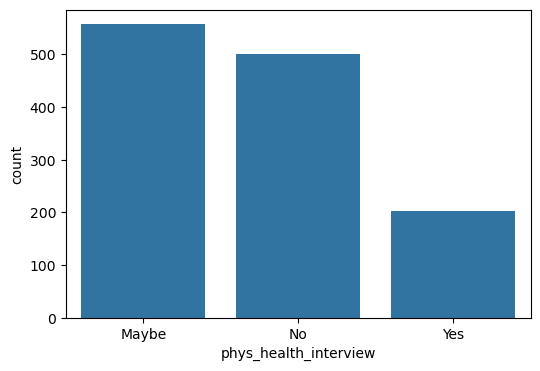

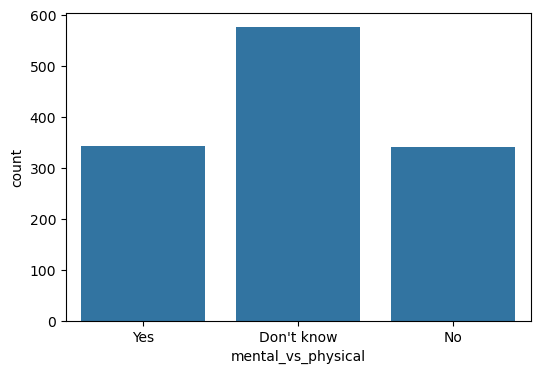

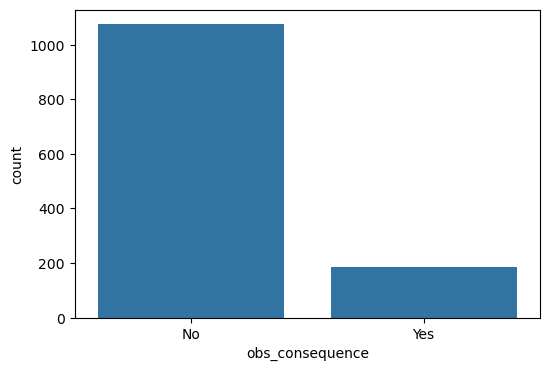

In [194]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df3[col])

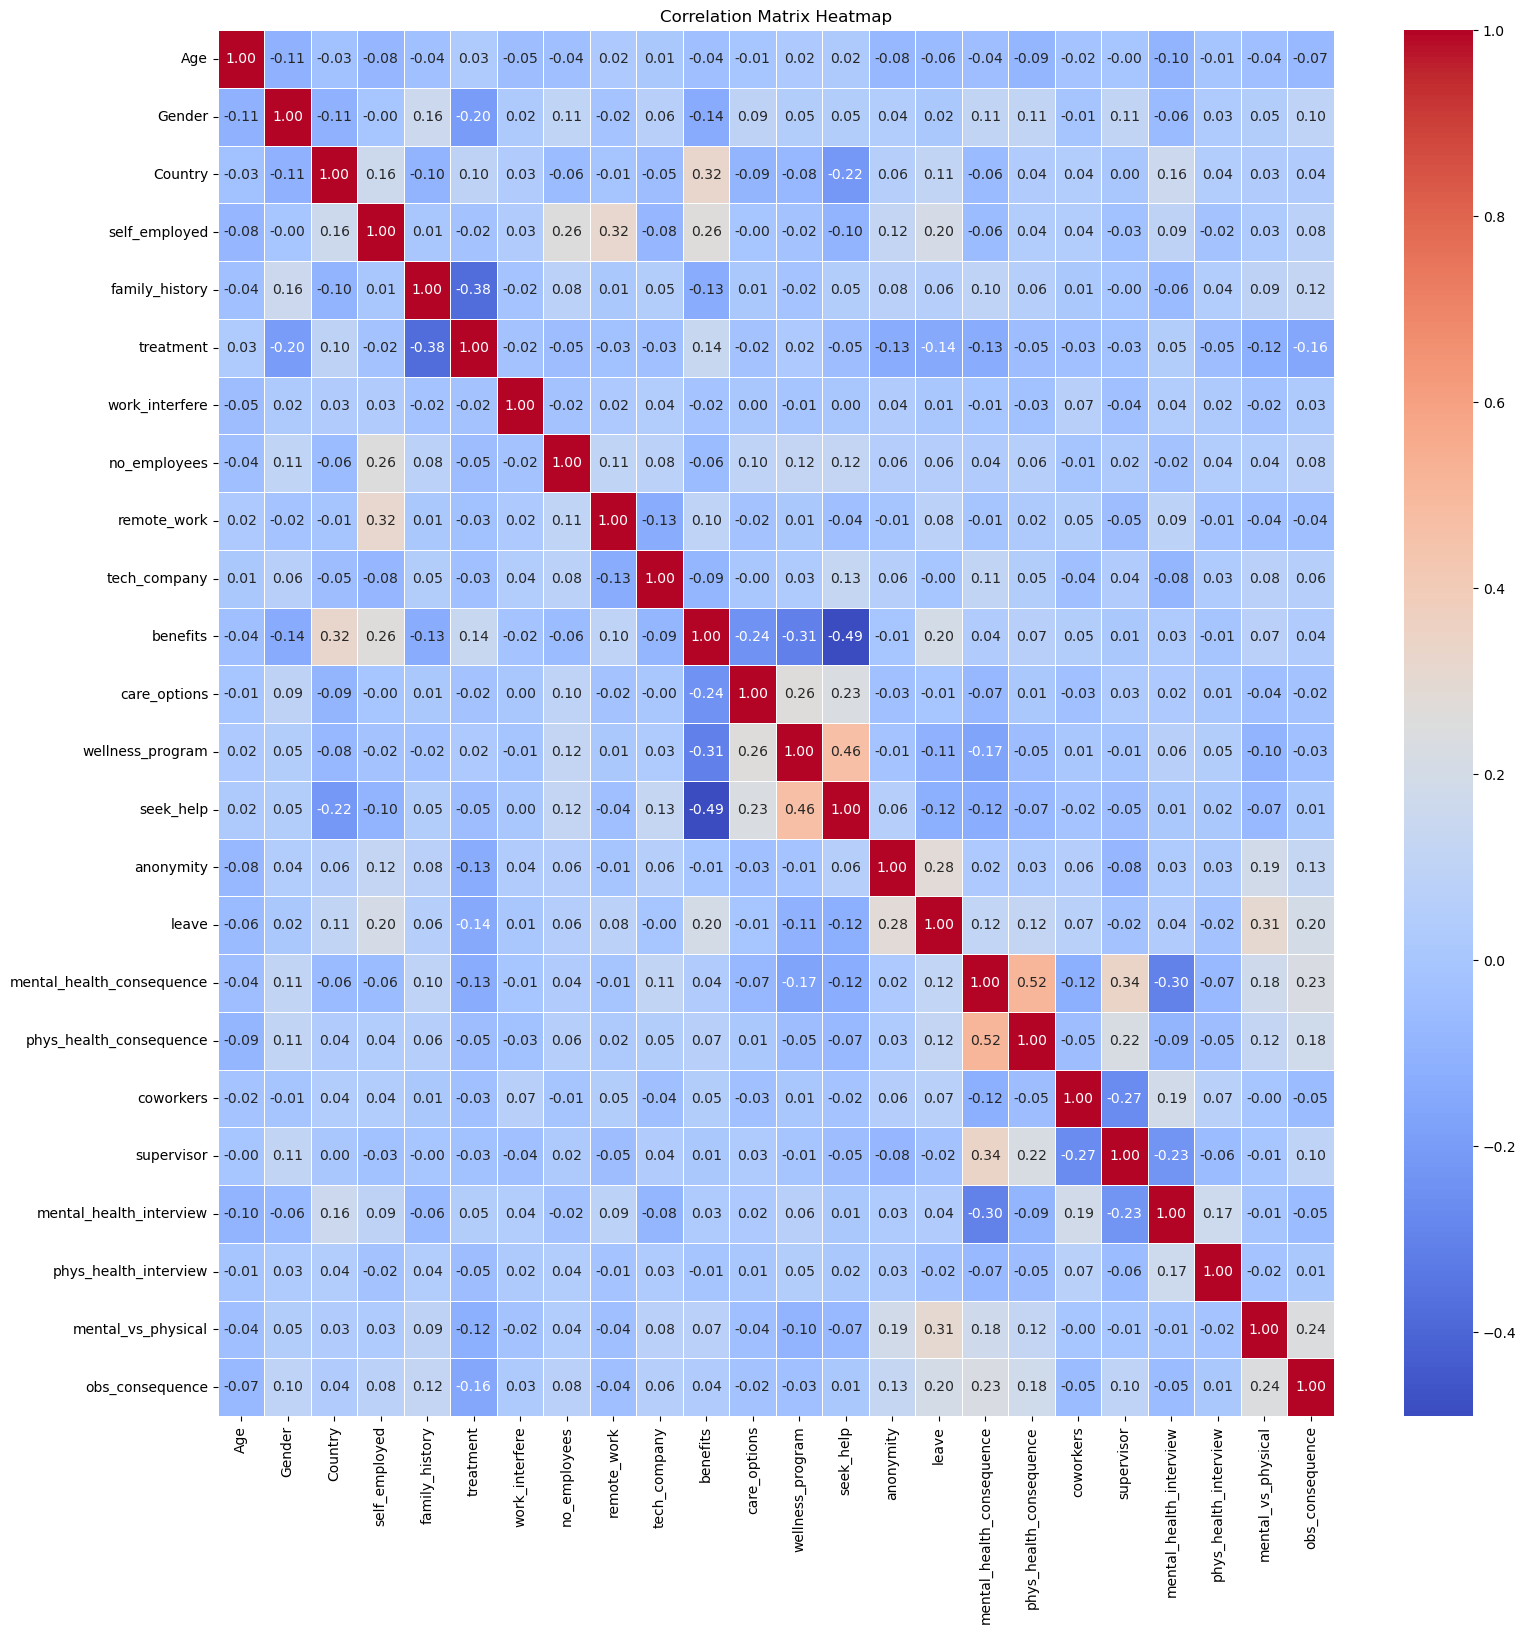

In [195]:

numeric_df = df.select_dtypes(include=['number'])


correlation_matrix = numeric_df.corr()


plt.figure(figsize=(18, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [196]:
df.head() 
#complete dataset is converted from categorical to numerical

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,2,6,2,2,2,1,6,2,2,...,2,4,3,3,3,3,3,3,2,2
1,44,3,6,2,2,1,2,4,2,1,...,3,5,2,3,2,2,3,2,3,2
2,32,3,3,2,2,1,2,6,2,2,...,3,2,3,3,1,3,1,1,1,2
3,31,3,5,2,1,2,1,5,2,2,...,1,2,1,1,3,2,2,3,1,1
4,31,3,6,2,2,1,3,3,1,2,...,3,5,3,3,3,3,1,1,3,2


## This preprocced dataset can be used for unsupervised learning_
## like - As there is no direct target columns